In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Setting the working directory
import os
os.chdir(r'd:\Dowry-Demand-Prediction')

In [4]:
data = pd.read_excel('Dataset\\encoded\\Dowry-Data-Bangladesh-encoded.xlsx')

In [5]:
from imblearn.over_sampling import RandomOverSampler

X = data.drop(columns=['dowry','dowry_money_log'])
y = data['dowry']

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [6]:
X.head()

,year,women's age,men's age,mohor_log,family type_Lower Class,family type_Poverty Level,family type_Rich Class,area_Barguna,area_Barishal,area_Bhola,...,boy's job_Day Labour,boy's job_Driver,boy's job_Farmer,boy's job_Service Holder,boy's job_Worker,marry condition_Forced Marriage,marry condition_Irrelevant Marriage,marry condition_Love Marriage,women married/unmarried_Single,women married/unmarried_Widow
0,2013,20,25,3.770285,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,2013,18,38,3.598551,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,2013,22,37,3.758029,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,2013,19,39,3.598551,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
4,2013,23,26,3.666751,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# 1. Random Forest (handles high-dim well)

In [8]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9694010416666666


In [9]:
# Optional: Cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest CV Accuracy: %.3f ± %.3f" % (rf_cv_scores.mean(), rf_cv_scores.std()))

Random Forest CV Accuracy: 0.930 ± 0.009


# 2. Logistic Regression with PCA (reduce dimensionality)

In [10]:
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train)
lr_pred = lr.predict(X_test_pca)
print("Logistic Regression (PCA) Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression (PCA) Accuracy: 0.3802083333333333


# 3. KNN with PCA (KNN is sensitive to high-dim)

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
knn_pred = knn.predict(X_test_pca)
print("KNN (PCA) Accuracy:", accuracy_score(y_test, knn_pred))

KNN (PCA) Accuracy: 0.8020833333333334


# 4. XGBoost (handles high-dim well)

In [12]:
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9192708333333334


# Metrices to check

## Confusion Matrix (with Heatmap)

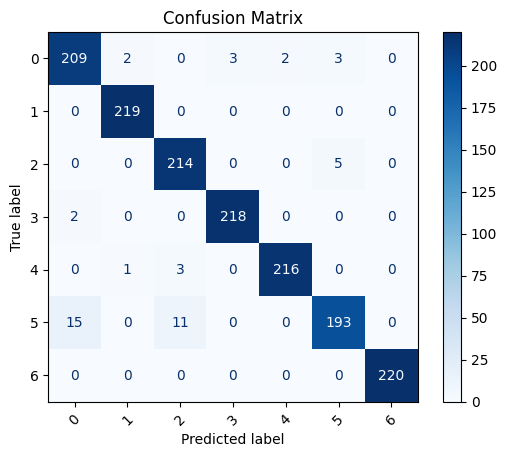

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predict using your rf
y_pred = rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


## 2. Classification Report

In [15]:
print(classification_report(y_test, rf_pred, digits=3))

              precision    recall  f1-score   support

           0      0.925     0.954     0.939       219
           1      0.986     1.000     0.993       219
           2      0.939     0.977     0.957       219
           3      0.986     0.991     0.989       220
           4      0.991     0.982     0.986       220
           5      0.960     0.881     0.919       219
           6      1.000     1.000     1.000       220

    accuracy                          0.969      1536
   macro avg      0.970     0.969     0.969      1536
weighted avg      0.970     0.969     0.969      1536



## 3. Feature Importance Plot

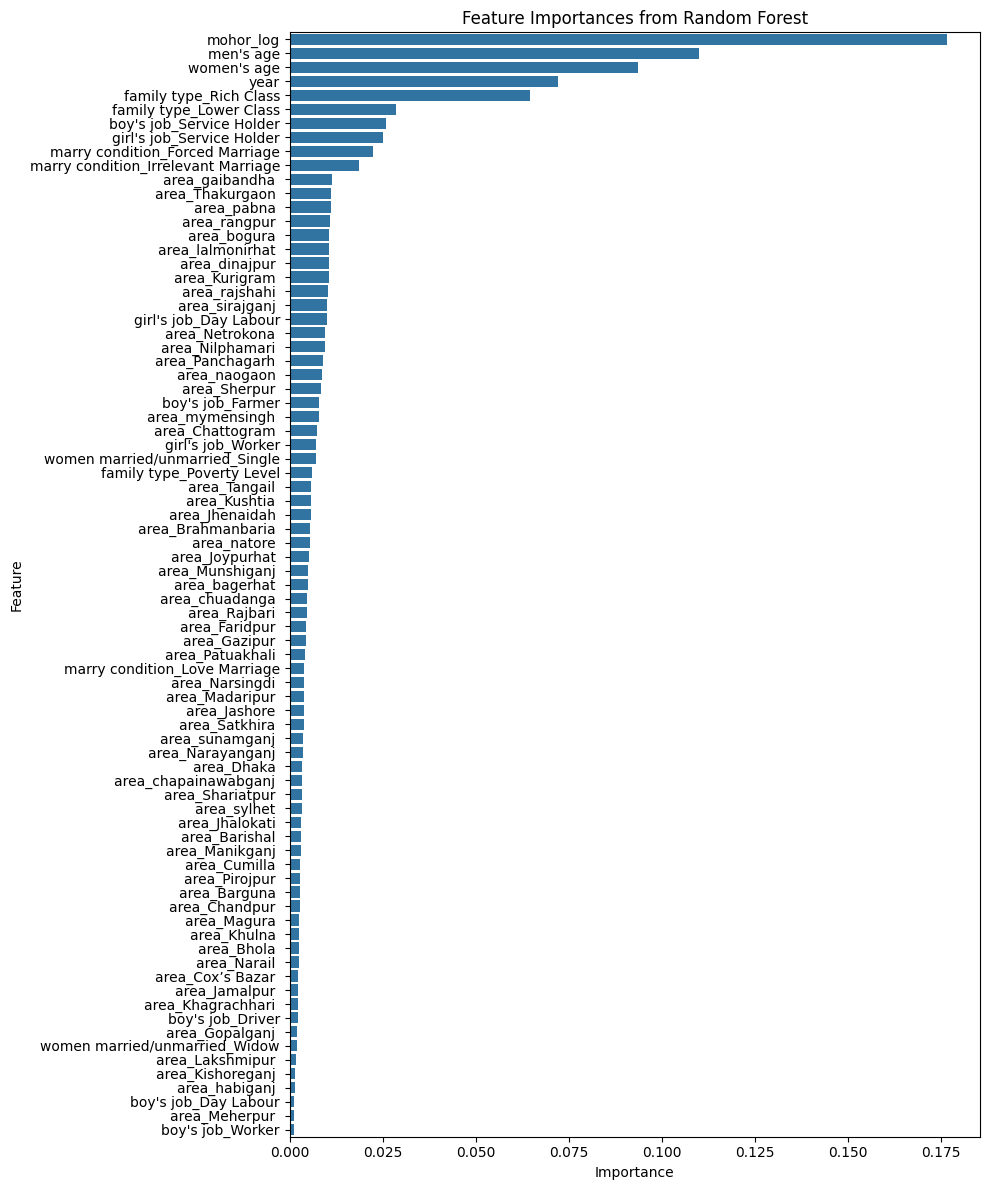

In [16]:
import pandas as pd
import numpy as np

# Get feature importances
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 12))
sns.barplot(x=importances[indices], y=features[indices])  # Remove palette
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [17]:
# save the model
import joblib
joblib.dump(rf, 'models/random_forest_model.pkl')

['models/random_forest_model.pkl']